# Lab cleanup Navigators


_Imports and Helpers_


In [1]:
import sys
print(sys.executable)

from navigator_types import SystematicNavigator
from navigators import BousPath, SkeletonPath, SpanningTreePath
import matplotlib.pyplot as plt
import utils as ut
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display
import rclpy
from nav_msgs.msg import OccupancyGrid, MapMetaData
from std_msgs.msg import Header

def show_imgs(imgs, labels):
    n = len(imgs)
    fig, ax = plt.subplots(1, n, figsize=(6*n, 6))

    if n == 1:
        ax = [ax]

    for i in range(n):
        img = cv2.normalize(imgs[i], None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(labels[i])
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()

def interactive_path_slider(
    map_img,
    paths,
    navigator,
    title="Interactive Path",
    color=(0, 255, 255),
    thickness=1,
    origin=np.array([0, 0])
    ):
    """
    Interactive slider visualization for planner paths.

    Parameters
    ----------
    map_img : np.ndarray
        Original occupancy map image.

    paths : list
        List of planner paths in world coordinates.

    navigator : SystematicNavigator
        Navigator instance containing map resolution and origin.

    title : str
        Figure title.

    color : tuple
        Path color in BGR.

    thickness : int
        Polyline thickness.
    """

    %matplotlib widget
    import matplotlib.pyplot as plt
    import ipywidgets as widgets
    from IPython.display import display
    import cv2
    import numpy as np

    plt.ion()

    # --------------------------------------------------
    # Convert world coordinates -> image pixels
    # --------------------------------------------------

    path_pixels = []

    for path in paths:
        path_pix = navigator.world_to_pixel_poly(path)
        path_pixels.extend(path_pix)

    path_pixels = np.array(path_pixels)

    # --------------------------------------------------
    # Create visualization image
    # --------------------------------------------------

    path_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

    cv2.polylines(
        path_img,
        [path_pixels.astype(np.int32)],
        isClosed=False,
        color=color,
        thickness=thickness
    )

    # --------------------------------------------------
    # Create interactive figure
    # --------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(path_img)
    ax.set_title(title)
    ax.axis("off")

    # moving robot dot
    robot_dot, = ax.plot(
        path_pixels[0, 0],
        path_pixels[0, 1],
        'o',
        color='yellow',
        markersize=10
    )

    # --------------------------------------------------
    # Slider widget
    # --------------------------------------------------

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(path_pixels) - 1,
        step=1,
        description='Waypoint:',
        continuous_update=True,
        layout=widgets.Layout(width='800px')
    )

    # --------------------------------------------------
    # Update callback
    # --------------------------------------------------

    def update_robot(change):

        idx = change['new']

        x = path_pixels[idx, 0]
        y = path_pixels[idx, 1]

        robot_dot.set_data([x], [y])

        fig.canvas.draw_idle()

    slider.observe(update_robot, names='value')

    display(slider)

    plt.show()

def create_occupancy_grid(path, resolution=0.05, origin=(0.0, 0.0)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Cannot load map: {path}")

    grid = np.full(img.shape, -1, dtype=np.int8)

    # standard ROS map convention
    grid[img < 250] = 100   # occupied
    grid[img >= 250] = 0    # free

    msg = OccupancyGrid()
    msg.header = Header()
    msg.header.frame_id = "map"
    msg.header.stamp = rclpy.clock.Clock().now().to_msg()

    msg.info = MapMetaData()
    msg.info.resolution = float(resolution)
    msg.info.width = img.shape[1]
    msg.info.height = img.shape[0]
    msg.info.origin.position.x = float(origin[0])
    msg.info.origin.position.y = float(origin[1])
    msg.info.origin.orientation.w = 1.0

    msg.data = grid.flatten().tolist()

    return msg

rclpy.init()

/workspaces/lcr/src/mirte_lc/.venv/bin/python


## Setup

In order to demonstrate the different navigators, a map must first be loaded into the notebook. \
We use a map provided by the [mirte navigation](https://github.com/MartijnWisse/mirte_navigation) ros2 package


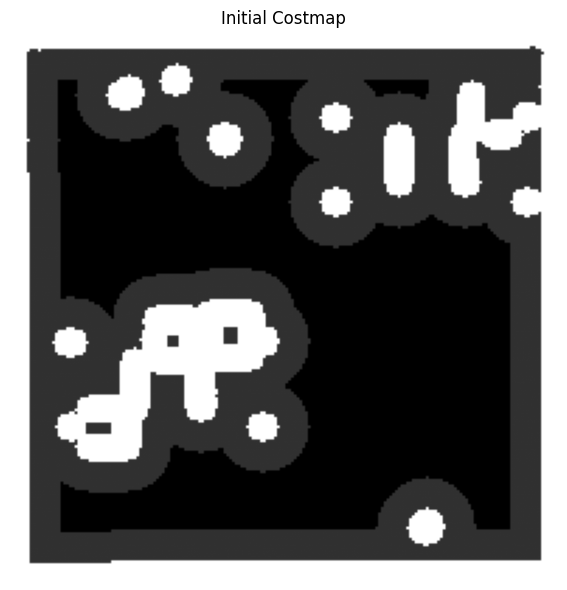

In [2]:
path = "maps/lc_costmap.pgm"
map_img = cv2.bitwise_not(cv2.imread(path, cv2.IMREAD_UNCHANGED))
map_msg = create_occupancy_grid(path)
show_imgs([map_img], ['Initial Costmap'])

## Systematic Navigator

Each defined navigator is a derived class of `SystematicNavigator`, a metaclass encompassing all navigators \
that plan coverage paths over the whole free space area. Standard for the derived classes is that they \
update their internal map and as a result plan a path over this map.

```update_map()``` first takes the costmap and, given a threshold, sets the free space to [0, 0, 0] and occupied space [255, 255, 255]. \
It then uses ```opencv.findContours()``` to find the free space boundaries and saves these as contours.



sorted polygons, moving on to group detection
Testing if contour [[6.325, 0.875], [6.525, 1.075], [6.525, 1.125], [6.625, 1.125], [6.675000000000001, 1.075], [6.875, 1.075], [6.925000000000001, 1.0250000000000001], [6.9750000000000005, 1.075], [7.175000000000001, 1.075], [7.2250000000000005, 1.125], [7.275, 1.125], [7.325, 1.175], [7.375, 1.175], [7.375, 1.125], [7.425000000000001, 1.075], [7.425000000000001, 0.875], [6.325, 0.875]] points is inside contour [[0.875, 0.875], [0.925, 4.7250000000000005], [1.8250000000000002, 5.075], [2.375, 4.325], [4.275, 4.175], [4.9750000000000005, 4.575], [5.375, 5.4750000000000005], [4.925000000000001, 6.275], [5.375, 7.025], [4.9750000000000005, 7.7250000000000005], [2.9250000000000003, 7.375], [2.325, 8.175], [0.925, 8.025], [0.925, 8.875], [6.4750000000000005, 8.825000000000001], [7.425000000000001, 7.875], [8.325000000000001, 8.825000000000001], [8.875, 8.825000000000001], [8.875, 3.7750000000000004], [7.525, 3.2750000000000004], [5.325, 3.725],

successfully grouped polygons
2


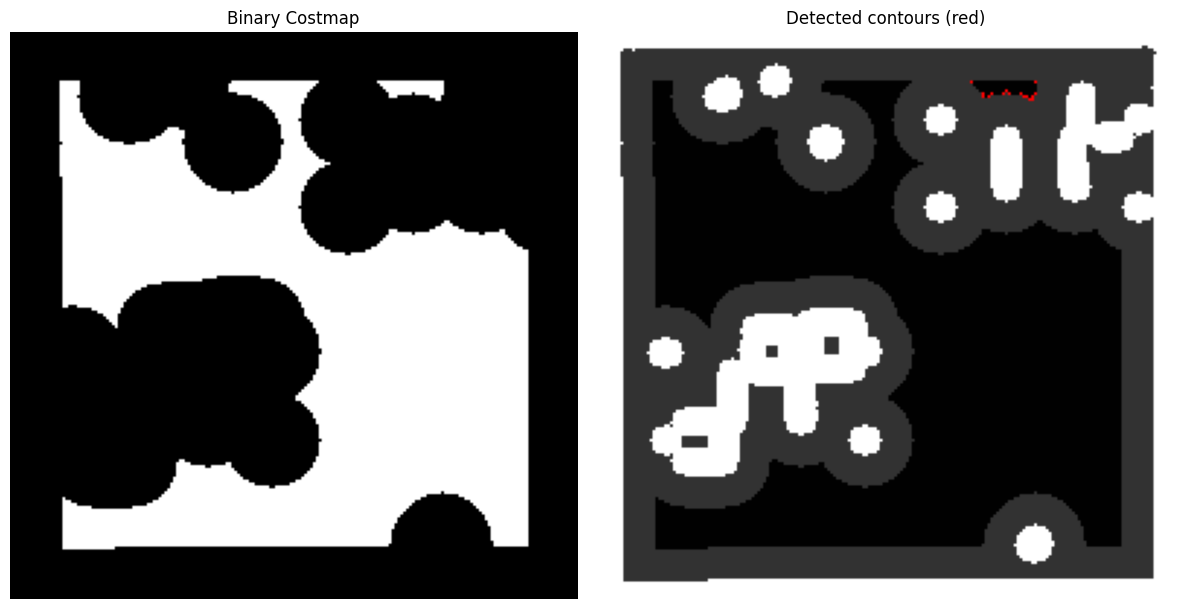

In [3]:
navigator = SystematicNavigator()

navigator.update_map(map_msg)
contours = navigator.contours
print(len(contours))
color_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)
contour_img = cv2.drawContours(color_img, contours[1], -1, (255, 0, 0), 1)

show_imgs([navigator.binary_costmap, contour_img], 
         ['Binary Costmap', 'Detected contours (red)'])

## BousPath
The first navigator that will be covered is a Boustropedon based Coverage planner. \
This navigator plans in two steps:
- Decomposition
- Swath Generation

### Boustropedon Cellular Decomposition

sorted polygons, moving on to group detection
Testing if contour [[6.325, 0.875], [6.525, 1.075], [6.525, 1.125], [6.625, 1.125], [6.675000000000001, 1.075], [6.875, 1.075], [6.925000000000001, 1.0250000000000001], [6.9750000000000005, 1.075], [7.175000000000001, 1.075], [7.2250000000000005, 1.125], [7.275, 1.125], [7.325, 1.175], [7.375, 1.175], [7.375, 1.125], [7.425000000000001, 1.075], [7.425000000000001, 0.875], [6.325, 0.875]] points is inside contour [[0.875, 0.875], [0.925, 4.7250000000000005], [1.8250000000000002, 5.075], [2.375, 4.325], [4.275, 4.175], [4.9750000000000005, 4.575], [5.375, 5.4750000000000005], [4.925000000000001, 6.275], [5.375, 7.025], [4.9750000000000005, 7.7250000000000005], [2.9250000000000003, 7.375], [2.325, 8.175], [0.925, 8.025], [0.925, 8.875], [6.4750000000000005, 8.825000000000001], [7.425000000000001, 7.875], [8.325000000000001, 8.825000000000001], [8.875, 8.825000000000001], [8.875, 3.7750000000000004], [7.525, 3.2750000000000004], [5.325, 3.725],

map decomposed, publishing decomposition
group size: 1
0: 17 points
Performing Decomposition
map decomposed, publishing decomposition


[WARN] [1780250190.188517945] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.


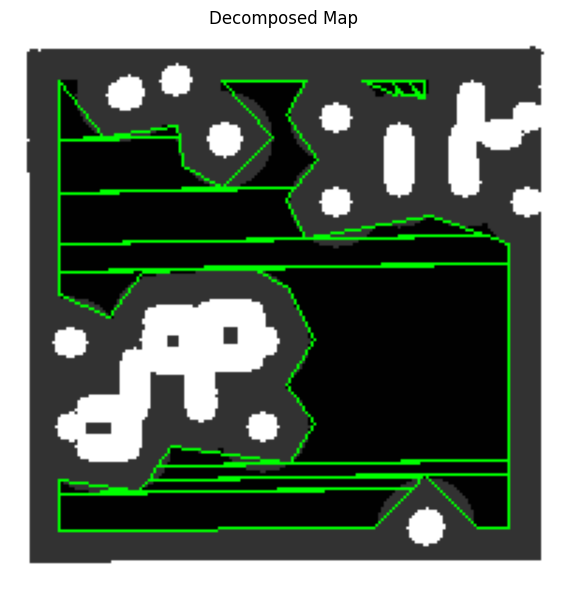

In [4]:
# Update internal map
navigator = BousPath()
navigator.update_map(map_msg)

pixel_cells = []
cells = []
display_cells = []

color_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

print("polymap groups:", len(navigator.polymap))

# Perform Boustrophedon Cellular Decomposition
for group in navigator.polymap:

    print("group size:", len(group))

    result = navigator.bcd(group)

    if not result:
        continue

    cells.append(result)
    display_cells.extend(result)

# -------------------------------------------------------
# Convert polygons -> OpenCV-compatible contours
# -------------------------------------------------------
pixel_cells = []

for poly in display_cells:

    pts = np.array(
        navigator.world_to_pixel_poly(poly.exterior.coords),
        dtype=np.int32
    )

    # OpenCV requires Nx1x2 format for contours
    pts = pts.reshape((-1, 1, 2))

    pixel_cells.append(pts)

# -------------------------------------------------------
# Draw result
# -------------------------------------------------------
decomp_img = cv2.drawContours(
    color_img,
    pixel_cells,
    contourIdx=-1,
    color=(0, 255, 0),
    thickness=1
)

show_imgs([decomp_img], ['Decomposed Map'])

### Boustrophedon Path Generation

Number of cells: 15
generating full trajectory
paths generated successfully


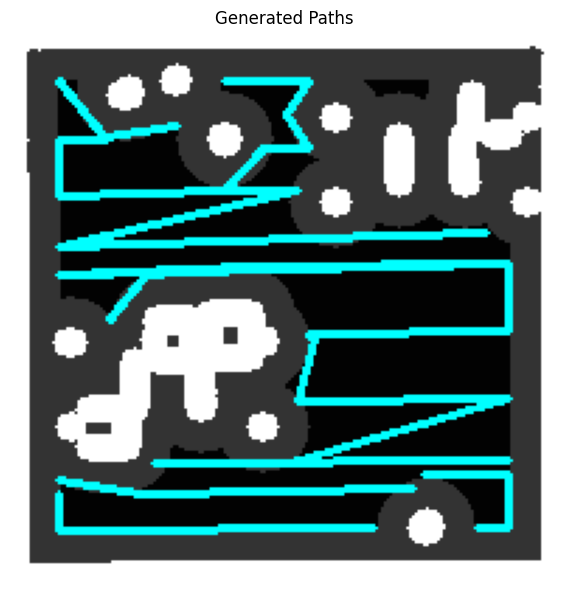

In [5]:
paths = []
# for cell in cells:
bous_paths = navigator.bous_path(cells[0])
paths.extend(bous_paths)

print('paths generated successfully')

swath_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)

for path in paths:
    pts = np.array(navigator.world_to_pixel_poly(path), dtype=np.int32)

    swath_img = cv2.polylines(
        swath_img,
        [pts],
        isClosed=False,
        color=(0, 255, 255),
        thickness=2
    )
show_imgs(
    [swath_img],
    ['Generated Paths']
)


IntSlider(value=0, description='Waypoint:', layout=Layout(width='800px'), max=57)

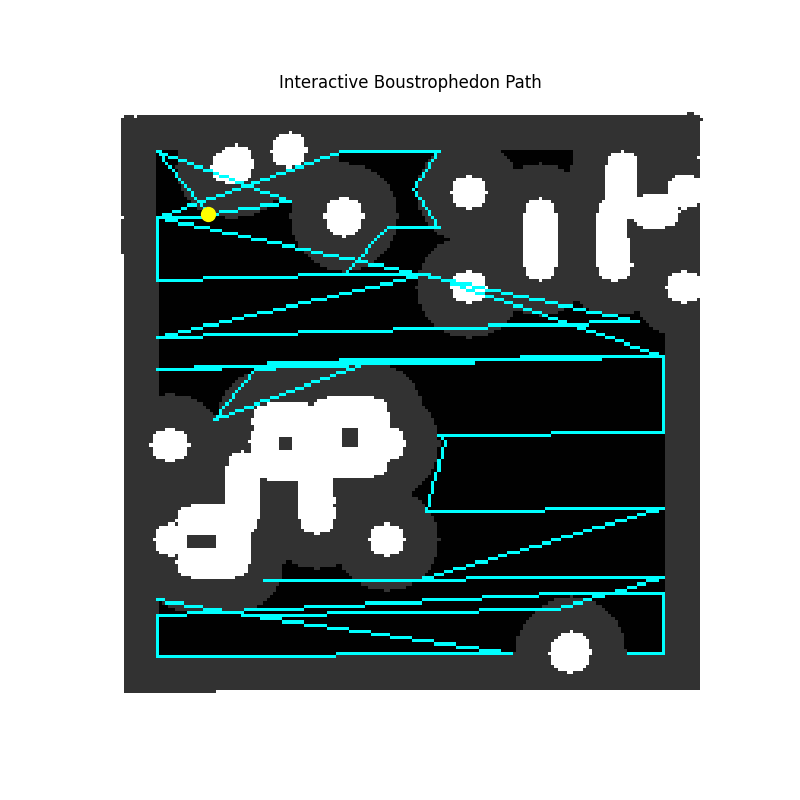

In [6]:
interactive_path_slider(
    map_img=map_img,
    paths=paths,
    navigator=navigator,
    title="Interactive Boustrophedon Path"
)

## SkeletonPath

The `SkeletonPath` planner is a topology-based coverage planner that generates navigation paths using the morphological skeleton of the environment.

Unlike the `BousPath` planner, which decomposes the free space into sweepable cells, the skeleton planner reduces the free space to a graph-like centerline representation. This representation preserves the connectivity of the environment while simplifying path planning.

The implementation is inspired by recent work in morphology-based exploration and autonomous navigation.

---

### Planner Initialization

The planner can be initialized similarly to the other navigators:

In [7]:
navigator = SkeletonPath()

navigator.update_map(map_msg)

sorted polygons, moving on to group detection
Testing if contour [[6.325000000000001, 0.8750000000000001], [6.525000000000001, 1.0750000000000002], [6.525000000000001, 1.1250000000000002], [6.625000000000001, 1.1250000000000002], [6.675000000000001, 1.0750000000000002], [6.875000000000001, 1.0750000000000002], [6.925000000000001, 1.0250000000000001], [6.9750000000000005, 1.0750000000000002], [7.175000000000001, 1.0750000000000002], [7.2250000000000005, 1.1250000000000002], [7.275000000000001, 1.1250000000000002], [7.325000000000001, 1.1750000000000003], [7.375000000000001, 1.1750000000000003], [7.375000000000001, 1.1250000000000002], [7.425000000000001, 1.0750000000000002], [7.425000000000001, 0.8750000000000001], [6.325000000000001, 0.8750000000000001]] points is inside contour [[0.8750000000000001, 0.8750000000000001], [0.9250000000000002, 4.7250000000000005], [1.8250000000000002, 5.075000000000001], [2.3750000000000004, 4.325000000000001], [4.275, 4.175000000000001], [4.975000000000

[WARN] [1780250190.602092385] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.


### Reading and Skeletonizing the Map

The skeleton planner generates a morphological skeleton using the `read()` method

Internally, the planner:
1. fills the free-space contours,
2. skeletonizes the free-space region,
3. extracts skeleton pixels,
4. converts them into Cartesian waypoints.

The generated waypoints are stored in `waypoints`

reading map
map read


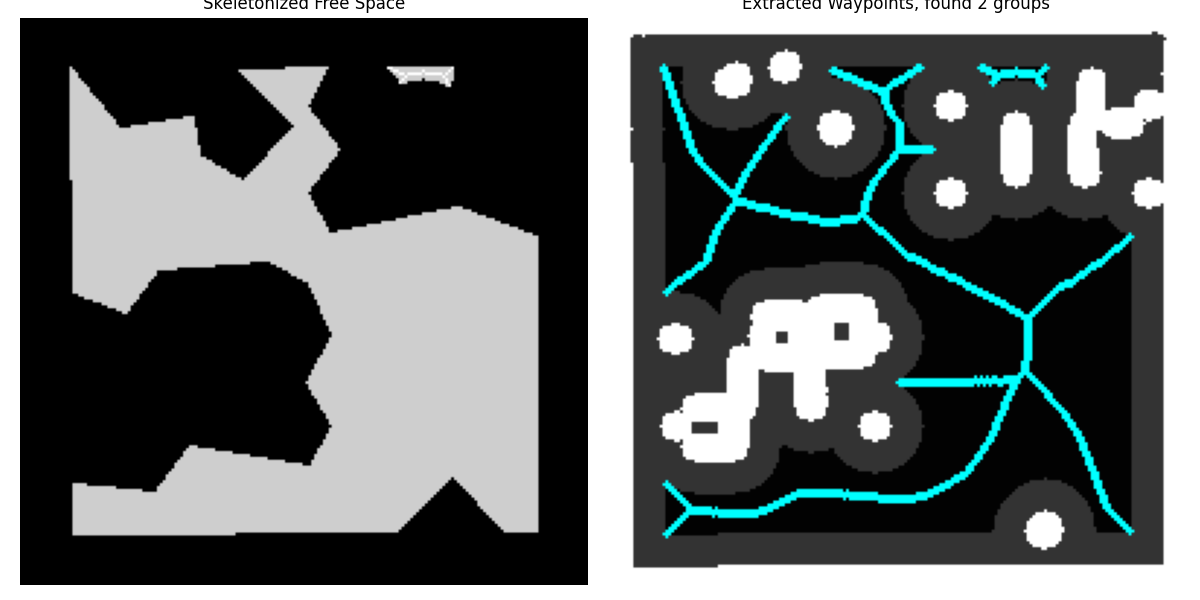

In [8]:
navigator.read()

skeleton_img = cv2.addWeighted(
    navigator.contour_map,
    0.8,
    navigator.skeleton_map,
    0.2,
    0,
)

# Convert grayscale map to RGB so we can draw colored points
waypoint_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

# Convert waypoint coordinates (meters) back to image pixels
pts = []
for group in navigator.waypoint_groups:
    waypoints = navigator.world_to_pixel_poly(group)
    pts.extend(waypoints)

# Draw every waypoint
for pt in pts:
    cv2.circle(
        waypoint_img,
        pt,
        radius=1,
        color=(0, 255, 255),
        thickness=-1
    )

show_imgs(
    [skeleton_img, waypoint_img],
    ['Skeletonized Free Space', f'Extracted Waypoints, found {len(navigator.waypoint_groups)} groups']
)

### Path Planning

After the waypoints have been generated, they are then sampled and ordered. \
The algorithm does this by first constructing a graph representation of the skeleton tree. \
The waypoints then become graph nodes. Edges are generated between the nodes with a certain distance threshold \
finding leaf nodes, meaning nodes with only one connection (green),

To efficiently identify neighboring points, a k-d tree is used for spatial indexing. \
Starting from the closest waypoint to the robot, the algorithm recursively explores nearby nodes and connects them within the graph,

Leaf nodes are then identified in the tree, (nodes with one connection).

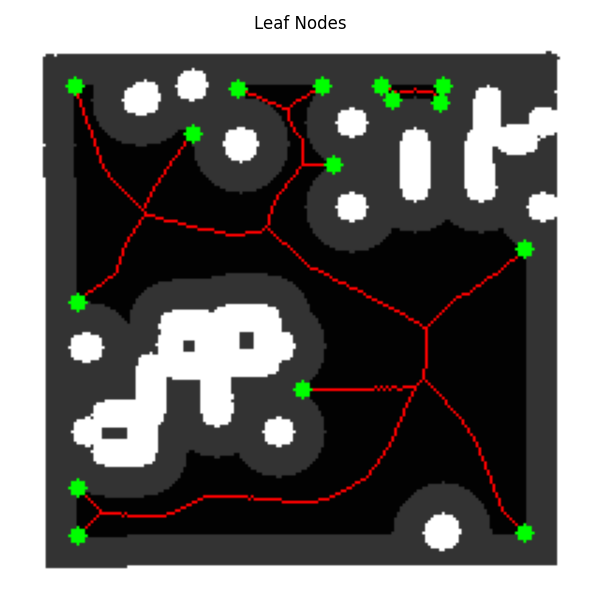

In [9]:
paths = []

graph_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

graphs = []
leaf_nodes = []   # will store (graph, node_id)

for waypoints in navigator.waypoint_groups:
    graph = navigator.set_waypoints(waypoints) 
    graphs.append(graph)

    # ---- draw edges (per graph, correct scope) ----
    for n1, n2 in graph.edges:

        p1 = graph.nodes[n1]['pos']
        p2 = graph.nodes[n2]['pos']
        
        pt1 = navigator.costmap.worldToMap(p1[0], p1[1])
        pt2 = navigator.costmap.worldToMap(p2[0], p2[1])

        cv2.line(graph_img, pt1, pt2, (255, 0, 0), 1)

        # ---- collect leaf nodes WITH GRAPH CONTEXT ----
        local_leaves = navigator.find_leaf_nodes(graph)
        leaf_nodes.extend([(graph, n) for n in local_leaves])


# ---- draw leaf nodes (FIXED: use correct graph) ----
for graph, node in leaf_nodes:

    point = graph.nodes[node]['pos']

    px, py = navigator.costmap.worldToMap(point[0], point[1])

    cv2.circle(
        graph_img,
        (px, py),
        radius=3,
        color=(0, 255, 0),
        thickness=-1
    )


show_imgs([graph_img], ['Leaf Nodes'])

### Path Ordering

First the closest leaf node to the robot is found, this is the starting position. \
The planner traces a path along the tree and selects the shortest one to the next leaf node. \
It then appends these points to the path and sets this new leaf node as the current one and marks it as visited. \
The algorithm repeats this process untill all leaf nodes have been explored successfully.

graphs: 2, groups: 2
planned path successfully
planned path successfully


IntSlider(value=0, description='Waypoint:', layout=Layout(width='800px'), max=908)

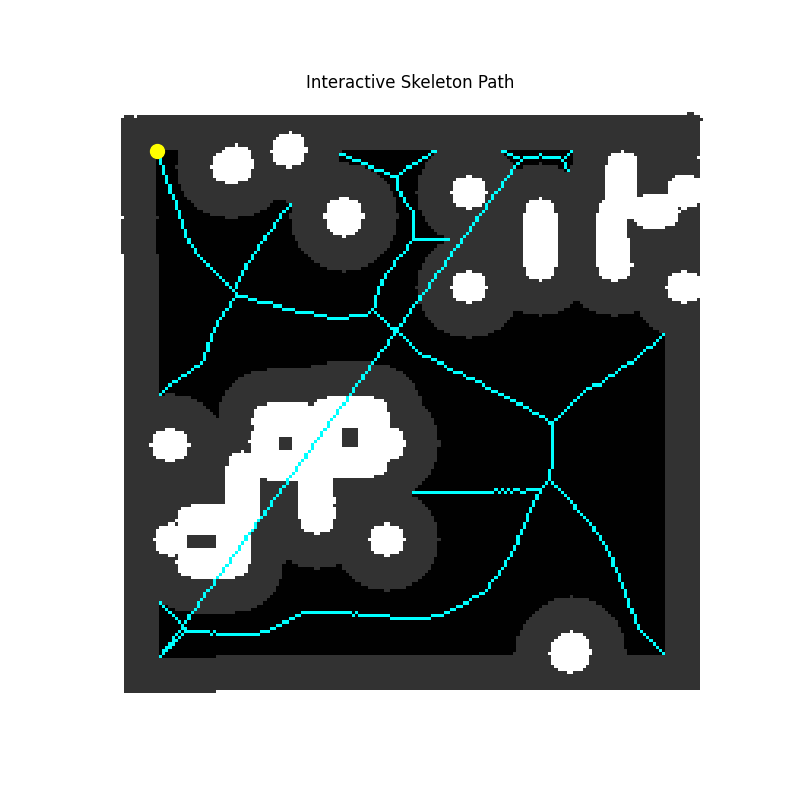

In [10]:
# Generate planner path
paths = []
start = np.array([0, 0])
print(f'graphs: {len(graphs)}, groups: {len(navigator.waypoint_groups)}')

for graph, waypoints in zip(graphs, navigator.waypoint_groups):
    path = navigator.plan_path(start, graph, waypoints)
    paths.append(path)
    start = path[-1]

interactive_path_slider(
    map_img=map_img,
    paths=paths,
    navigator=navigator,
    title="Interactive Skeleton Path"
)

# Spanning Tree Coverage Path

The spanning tree coverage path planner generates a path that covers the entire free space of the map \
by firs discretizing the free space into a grid and then adding nodes into each pixel. \
It then performs a depth-first traversal of the nodes, creating a tree. \
This tree is then circumnavigated to create a coverage path.

In [11]:
navigator = SpanningTreePath(scale=0.05)
navigator.update_map(map_msg)


sorted polygons, moving on to group detection
Testing if contour [[6.325000000000001, 0.8750000000000001], [6.525000000000001, 1.0750000000000002], [6.525000000000001, 1.1250000000000002], [6.625000000000001, 1.1250000000000002], [6.675000000000001, 1.0750000000000002], [6.875000000000001, 1.0750000000000002], [6.925000000000001, 1.0250000000000001], [6.9750000000000005, 1.0750000000000002], [7.175000000000001, 1.0750000000000002], [7.2250000000000005, 1.1250000000000002], [7.275000000000001, 1.1250000000000002], [7.325000000000001, 1.1750000000000003], [7.375000000000001, 1.1750000000000003], [7.375000000000001, 1.1250000000000002], [7.425000000000001, 1.0750000000000002], [7.425000000000001, 0.8750000000000001], [6.325000000000001, 0.8750000000000001]] points is inside contour [[0.8750000000000001, 0.8750000000000001], [0.9250000000000002, 4.7250000000000005], [1.8250000000000002, 5.075000000000001], [2.3750000000000004, 4.325000000000001], [4.275, 4.175000000000001], [4.975000000000

[WARN] [1780250190.974950167] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.


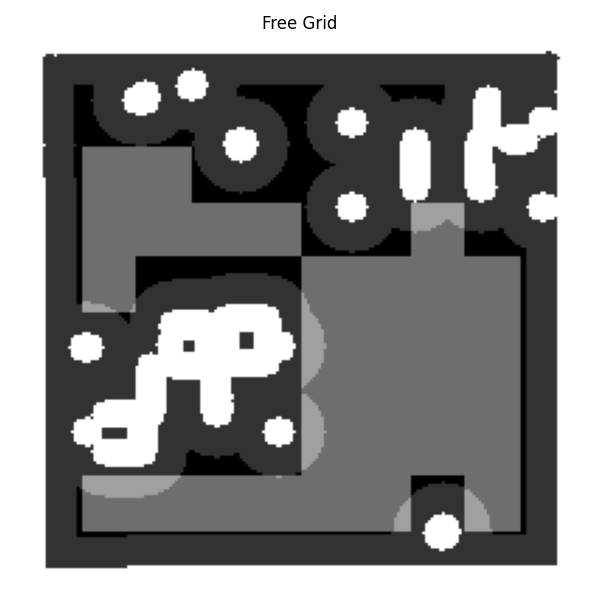

In [12]:
grid = navigator.sample_map()

overlay = cv2.resize(
    grid,
    (map_img.shape[1], map_img.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

result = cv2.addWeighted(
    map_img,
    0.7,
    overlay,
    0.3,
    0
)

show_imgs([result], 
         ['Free Grid'])



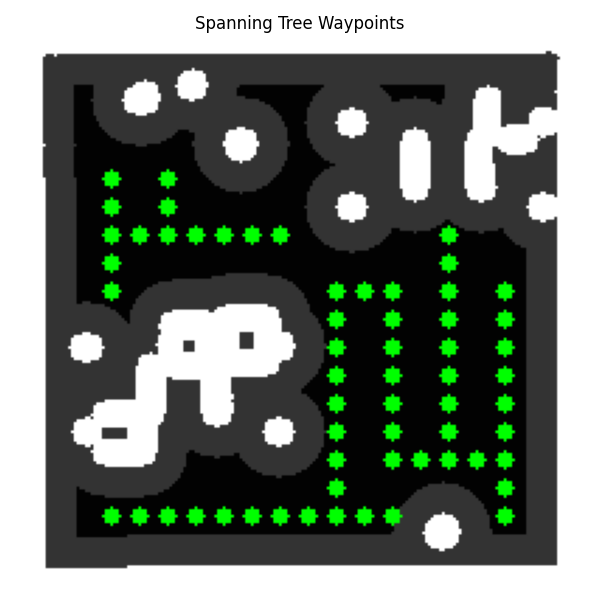

In [13]:
navigator.read()

tree_field = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)
for point in navigator.tree_points:
    cv2.circle(
        tree_field,
        point,
        radius=3,
        color=(0, 255, 0),
        thickness=-1
    )

show_imgs([tree_field],
         ['Spanning Tree Waypoints'])


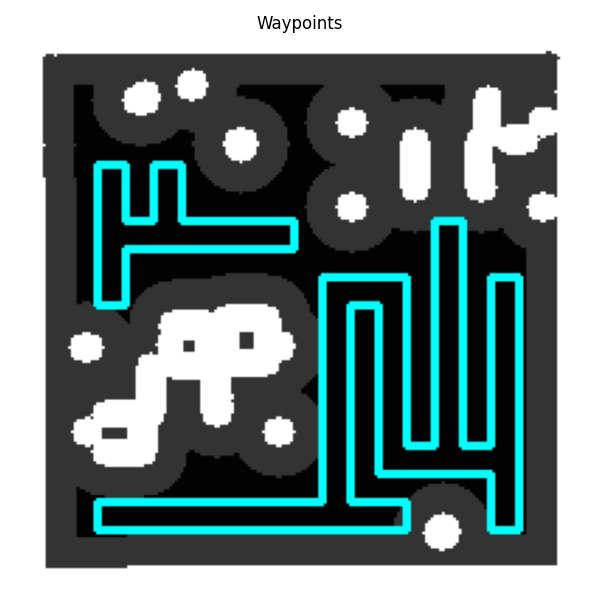

In [14]:
waypoint_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

contours = []

for group in navigator.waypoint_groups:

    contour = navigator.world_to_pixel_poly(group)

    contour = np.asarray(contour, dtype=np.int32)

    if len(contour) > 0:
        contours.append(contour)

cv2.drawContours(
    waypoint_img,
    contours,
    -1,
    (0, 255, 255),
    2
)

show_imgs([waypoint_img], ["Waypoints"])

planned path successfully
planned path successfully


IntSlider(value=0, description='Waypoint:', layout=Layout(width='800px'), max=46)

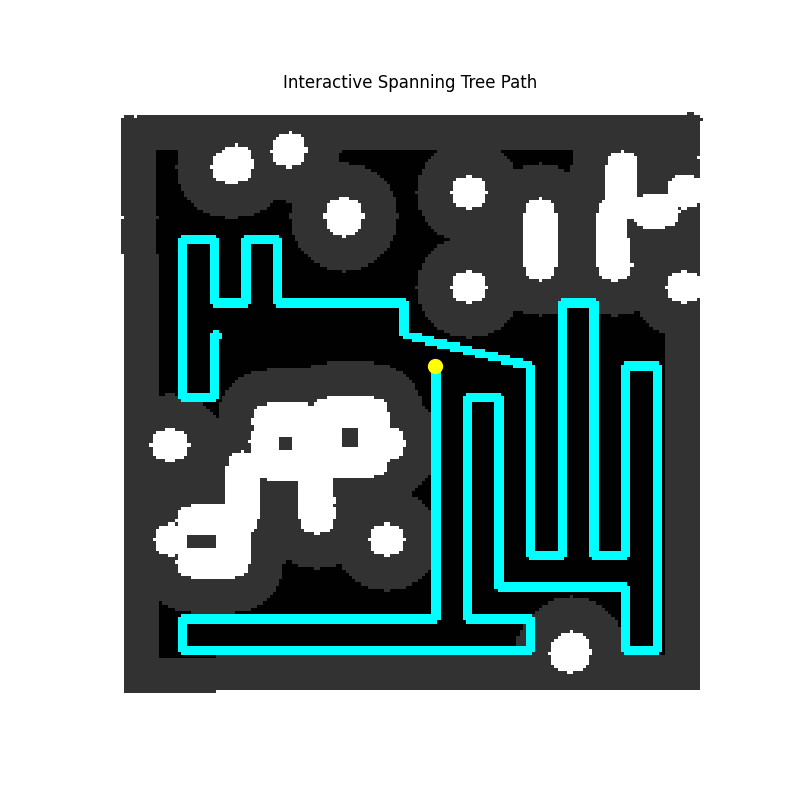

In [15]:
start = np.zeros(2, dtype=np.float32)

navigator.paths = []

for waypoints in navigator.waypoint_groups:
    graph = navigator.set_waypoints(waypoints)

    path = navigator.plan_path(
        start,
        graph,
        waypoints,
    )

    navigator.paths.append(path)

    start = np.asarray(path[-1]).reshape(2,)

# Interactive visualization
interactive_path_slider(
    map_img=map_img,
    paths=navigator.paths,
    navigator=navigator,
    title="Interactive Spanning Tree Path",
    color=(0, 255, 255),
    thickness=2,
)